# **Customer Churn Prediction Platform for Retail Business Using Machine Learning and MLOps - Model Experiment**

---

## **Import Library**

---

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import machine learning models and evaluation metrics
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

# Import advanced machine learning models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

---

## **Load Data**

---

In [2]:
# Define file paths and target column
TRAIN_DATA_PATH = "../data/processed/train.csv"
TEST_DATA_PATH = "../data/processed/test.csv"

# Define the target column for prediction
TARGET_COLUMN = "churn_flag"

# Load the training and testing datasets
train_df = pd.read_csv(TRAIN_DATA_PATH)
test_df = pd.read_csv(TEST_DATA_PATH)

In [3]:
# Display the first few rows of the training dataset
train_df.head()

,num__purchase_frequency,num__avg_order_value,num__total_spent,num__recency_days,num__website_visits,num__discount_usage_rate,num__email_open_rate,num__cart_abandonment_rate,num__loyalty_score,num__engagement_score,...,cat__customer_segment_Returning,cat__customer_segment_VIP,cat__preferred_channel_In-Store,cat__preferred_channel_Mobile App,cat__preferred_channel_Online,cat__risk_segment_Critical Risk,cat__risk_segment_High Risk,cat__risk_segment_Low Risk,cat__risk_segment_Medium Risk,churn_flag
0,-0.682986,-0.761699,-0.606332,-1.584302,-0.565563,-0.396897,0.471760,-0.266327,-0.058059,0.527209,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0
1,0.014682,-0.638620,-0.234016,-1.422761,-0.005819,0.155764,-0.547079,-1.480694,1.135398,0.616482,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0
2,-0.264385,-1.317743,-0.507178,-0.444010,-0.234805,0.432095,1.327584,-0.353068,-1.713498,1.211637,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0
3,-0.473686,-0.426651,-0.431940,0.173648,-0.412905,0.938701,0.757035,0.297486,-0.866529,0.348663,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1
4,-0.752753,-1.622068,-0.661917,-0.634059,-0.654613,-0.489007,1.694366,0.470966,-1.559504,0.914059,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0


In [4]:
# Display the first few rows of the testing dataset
test_df.head()

,num__purchase_frequency,num__avg_order_value,num__total_spent,num__recency_days,num__website_visits,num__discount_usage_rate,num__email_open_rate,num__cart_abandonment_rate,num__loyalty_score,num__engagement_score,...,cat__customer_segment_Returning,cat__customer_segment_VIP,cat__preferred_channel_In-Store,cat__preferred_channel_Mobile App,cat__preferred_channel_Online,cat__risk_segment_Critical Risk,cat__risk_segment_High Risk,cat__risk_segment_Low Risk,cat__risk_segment_Medium Risk,churn_flag
0,0.014682,-0.938021,-0.284831,-0.491522,0.108674,-0.903503,-0.954614,0.514337,-1.559504,-1.049950,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1
1,1.619320,-1.585873,-0.290850,0.563248,2.309483,-1.317999,-1.525164,-0.396438,0.981403,-0.841646,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0
2,0.572817,-0.073186,0.315592,-1.166195,1.202718,1.399251,1.083063,-0.873510,-1.251515,1.390183,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0
3,0.572817,0.369534,0.759239,-0.700576,0.083231,0.432095,-1.688178,-1.480694,-0.558541,-0.216734,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0
4,-0.473686,0.994776,-0.287996,-1.565298,-0.578284,0.386039,0.920049,-1.220472,0.172933,1.509214,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0


**Insight:**

Data loaded succesfully

---

## **Model Training**

---

In [5]:
# Prepare the data for modeling
X_train = train_df.drop(columns=[TARGET_COLUMN])
y_train = train_df[TARGET_COLUMN]

# Prepare the test data
X_test = test_df.drop(columns=[TARGET_COLUMN])
y_test = test_df[TARGET_COLUMN]

# Display the shapes of the training and testing datasets
X_train.shape, X_test.shape

((80000, 83), (20000, 83))

In [6]:
# Clean column names by replacing spaces with underscores
X_train.columns = X_train.columns.str.replace(r"\s+", "_", regex=True)
X_test.columns = X_test.columns.str.replace(r"\s+", "_", regex=True)

In [7]:
# Define the machine learning models to be evaluated
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        class_weight="balanced",
        random_state=42,
    ),
}

In [8]:
# Evaluate each model and store the results
results = []

# Train each model, make predictions, and calculate evaluation metrics
trained_models = {}

# Loop through each model, fit it to the training data, and evaluate its performance on the test data
for model_name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "pr_auc": average_precision_score(y_test, y_proba),
    }

    results.append(metrics)
    trained_models[model_name] = model

# Create a DataFrame to display the evaluation results for all models, sorted by recall, pr_auc, and f1_score
results_df = pd.DataFrame(results).sort_values(
    by=["recall", "pr_auc", "f1_score"],
    ascending=False,
)

# Display the evaluation results for all models
results_df

[LightGBM] [Info] Number of positive: 36979, number of negative: 43021
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016203 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9272
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 83
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


,model,accuracy,precision,recall,f1_score,roc_auc,pr_auc
3,LightGBM,0.94355,0.933547,0.945160,0.939317,0.989781,0.988471
0,Logistic Regression,0.94415,0.935397,0.944402,0.939878,0.990367,0.989141
2,XGBoost,0.94440,0.939194,0.940617,0.939905,0.990038,0.988765
1,Random Forest,0.94460,0.939885,0.940292,0.940089,0.989396,0.987835


In [9]:
# Identify the best-performing model based on the evaluation metrics
champion_model_name = results_df.iloc[0]["model"]
champion_model = trained_models[champion_model_name]

champion_model_name

'LightGBM'

**Insight:**

At this stage, several classification models were trained and evaluated, including Logistic Regression, Random Forest, XGBoost, and LightGBM, using a training dataset with 80,000 rows and 83 features, and a testing dataset with 20,000 rows and 83 features. Each model was trained using `X_train` and `y_train`, then used to generate class predictions (`y_pred`) and positive-class probabilities (`y_proba`) to calculate evaluation metrics such as accuracy, precision, recall, F1-score, ROC-AUC, and PR-AUC. The results show that all models performed very well, with accuracy around 94% and ROC-AUC close to 0.99. LightGBM was selected as the best model because the evaluation results were sorted based on recall, PR-AUC, and F1-score, and LightGBM achieved the highest recall score of 0.945160. This means that LightGBM was the most effective model in identifying positive-class observations and reducing false negatives compared to the other models. However, the other models also showed strong performance, with Random Forest achieving the highest accuracy and F1-score, while Logistic Regression achieved the highest ROC-AUC and PR-AUC. Therefore, selecting LightGBM is appropriate if the main objective is to maximize recall, but further evaluation such as confusion matrix analysis, threshold tuning, and feature importance analysis should still be conducted before final model deployment.

---

## **Model Testing**

---

In [10]:
# Generate predictions and evaluate the champion model using a confusion matrix
y_pred = champion_model.predict(X_test)

# Create a confusion matrix to evaluate the performance of the champion model on the test data
cm = confusion_matrix(y_test, y_pred)
cm

array([[10133,   622],
       [  507,  8738]])

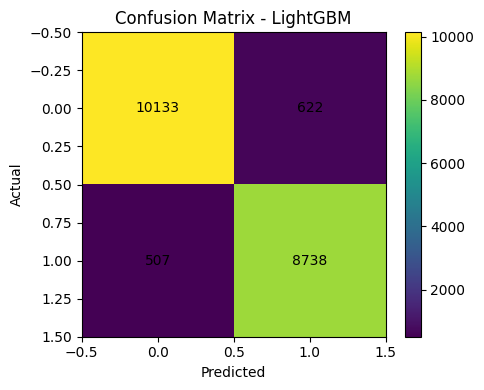

In [11]:
# Visualize the confusion matrix using a heatmap
plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title(f"Confusion Matrix - {champion_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

In [12]:
# Display the classification report for the champion model 
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.94      0.95     10755
           1       0.93      0.95      0.94      9245

    accuracy                           0.94     20000
   macro avg       0.94      0.94      0.94     20000
weighted avg       0.94      0.94      0.94     20000



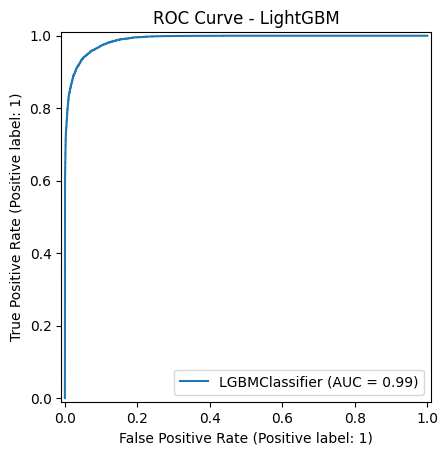

In [13]:
# Visualize the ROC curve for the champion model 
RocCurveDisplay.from_estimator(champion_model, X_test, y_test)
plt.title(f"ROC Curve - {champion_model_name}")
plt.show()

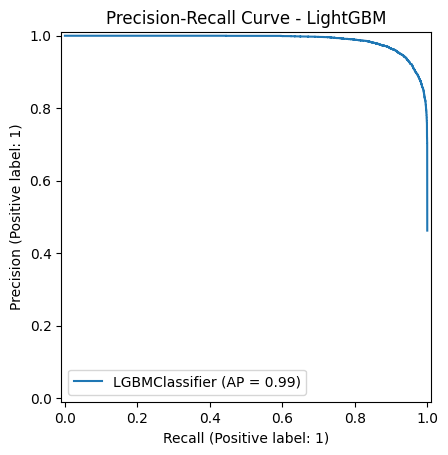

In [14]:
# Visualize the Precision-Recall curve for the champion model
PrecisionRecallDisplay.from_estimator(champion_model, X_test, y_test)
plt.title(f"Precision-Recall Curve - {champion_model_name}")
plt.show()

**Insight:**

The **LightGBM** model shows very strong performance on the testing dataset of **20,000 observations**. Based on the confusion matrix, the model correctly predicted **10,133 class 0 observations** as class 0, which are the **True Negatives**, and correctly predicted **8,738 class 1 observations** as class 1, which are the **True Positives**. The model made **622 False Positive** errors, meaning some actual class 0 observations were incorrectly predicted as class 1, and **507 False Negative** errors, meaning some actual class 1 observations were incorrectly predicted as class 0. The relatively low number of False Negatives indicates that the model is effective at identifying positive-class cases. From the classification report, the model achieved an overall **accuracy of 94%**, with balanced performance across both classes. For class 0, the model achieved a **precision of 0.95**, **recall of 0.94**, and **F1-score of 0.95**. For class 1, it achieved a **precision of 0.93**, **recall of 0.95**, and **F1-score of 0.94**. The high recall for class 1 shows that LightGBM successfully captures most of the actual positive cases. In addition, the ROC curve shows an **AUC score of 0.99**, indicating excellent ability to distinguish between class 0 and class 1. The Precision-Recall curve also shows an **Average Precision score of 0.99**, meaning the model maintains high precision while achieving high recall. Overall, LightGBM is a highly effective model for this classification task, especially when the main objective is to maximize positive-class detection and reduce False Negatives. One minor note is that the ROC curve appears twice in the notebook, so one duplicate plot can be removed to make the analysis cleaner.

---